# Performance and Valuation Insights: Bayer 04 Leverkusen's 2023/24 Bundesliga Season

This notebook presents a portfolio-style football analytics case study centered on **Bayer 04 Leverkusen's historic 2023/24 Bundesliga campaign**.

It focuses on three questions:

- *How dominant was Bayer 04 Leverkusen in Bundesliga 2023/24?*
- *Which players stood out in goals, assists, minutes, and market value?*
- *How much of player market value can be explained by simple season-level performance signals?*

The workflow combines **DuckDB**, **pandas**, **Matplotlib/Seaborn**, and **scikit-learn**.  
To improve reproducibility, the notebook reads the Transfermarkt dataset **remotely via DuckDB**.

### Author: Moritz Philipp Haaf, BSc MA
**Email:** itzmore.dev@gmail.com

**GitHub Repo:** [itzmore-mph/bundesliga-performance-analysis](https://github.com/itzmore-mph/bundesliga-performance-analysis)

## Executive Summary

This notebook analyzes Bayer 04 Leverkusen's 2023/24 Bundesliga season through a reproducible football analytics workflow.

It is organized around one clear analytical scope:
- **competition:** Bundesliga (`L1`)
- **season window:** 2023/08/01 to 2024/05/31
- **club:** Bayer 04 Leverkusen

The notebook is structured for GitHub readability and reproducibility:
- one central configuration block,
- remote data access through DuckDB,
- season-scoped filtering,
- consistent variable naming,
- and modeling steps that can be rerun top to bottom.

## 1. Initial Setup

Import libraries, define notebook configuration, and prepare a project root for optional figure exports.

In [1]:
# 1. Initial Setup

from pathlib import Path
import warnings
import re

import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

from adjustText import adjust_text
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")

def find_project_root(start_path: Path) -> Path:
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "README.md").exists() or (candidate / ".git").exists():
            return candidate
    return current

PROJECT_ROOT = find_project_root(Path.cwd())
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SEASON_LABEL = "2023/24"
SEASON_START = pd.Timestamp("2023-08-01")
SEASON_END = pd.Timestamp("2024-05-31")

TARGET_COMPETITION_ID = "L1"
TARGET_CLUB_NAME = "Bayer 04 Leverkusen Fußball"
DISPLAY_CLUB_NAME = "Bayer 04 Leverkusen"

BASE_URL = "https://pub-e682421888d945d684bcae8890b0ec20.r2.dev/data"

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Remote data source: {BASE_URL}")

Project root: C:\Users\morhaaf\Dev\Git\bundesliga-performance-analysis
Figures directory: C:\Users\morhaaf\Dev\Git\bundesliga-performance-analysis\figures
Remote data source: https://pub-e682421888d945d684bcae8890b0ec20.r2.dev/data


## 2. Load, Validate, and Preprocess Data with pandas

Load the core Transfermarkt tables remotely via DuckDB, standardize column names, parse dates, run lightweight fail-fast validation checks, and build season-specific analysis subsets.


In [2]:
# 2.1 Load remote tables via DuckDB
TABLE_NAMES = [
    "appearances",
    "club_games",
    "clubs",
    "competitions",
    "game_events",
    "games",
    "player_valuations",
    "players",
]

remote_con = duckdb.connect(database=":memory:")

try:
    remote_con.execute("INSTALL httpfs;")
    remote_con.execute("LOAD httpfs;")
except Exception as e:
    raise RuntimeError(
        "DuckDB httpfs extension could not be installed or loaded. "
        "Please check internet access and DuckDB extension availability."
    ) from e

def load_remote_table(table_name: str) -> pd.DataFrame:
    query = f"""
    SELECT *
    FROM read_csv_auto('{BASE_URL}/{table_name}.csv.gz')
    """
    return remote_con.execute(query).df()

tables = {name: load_remote_table(name) for name in TABLE_NAMES}

summary = pd.DataFrame(
    {
        "table": list(tables.keys()),
        "rows": [df.shape[0] for df in tables.values()],
        "columns": [df.shape[1] for df in tables.values()],
    }
)
display(summary)

print("\nTable schemas:")
for name, df in tables.items():
    print(f"  {name}: {df.columns.tolist()}")

,table,rows,columns
0,appearances,1824008,13
1,club_games,161014,11
2,clubs,451,17
3,competitions,49,11
4,game_events,1139579,11
5,games,80507,23
6,player_valuations,526185,6
7,players,37579,26



Table schemas:
  appearances: ['appearance_id', 'game_id', 'player_id', 'player_club_id', 'player_current_club_id', 'date', 'player_name', 'competition_id', 'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played']
  club_games: ['game_id', 'club_id', 'own_goals', 'own_position', 'own_manager_name', 'opponent_id', 'opponent_goals', 'opponent_position', 'opponent_manager_name', 'hosting', 'is_win']
  clubs: ['club_id', 'club_code', 'name', 'domestic_competition_id', 'total_market_value', 'squad_size', 'average_age', 'foreigners_number', 'foreigners_percentage', 'national_team_players', 'stadium_name', 'stadium_seats', 'net_transfer_record', 'coach_name', 'last_season', 'filename', 'url']
  competitions: ['competition_id', 'competition_code', 'name', 'sub_type', 'type', 'country_id', 'country_name', 'domestic_league_code', 'confederation', 'url', 'is_major_national_league']
  game_events: ['game_event_id', 'date', 'game_id', 'minute', 'type', 'club_id', 'club_name', 'player_id'

In [3]:
# 2.2 Helper: snake_case conversion and table unpacking
def to_snake(col: str) -> str:
    s1 = re.sub(r"(.)([A-Z][a-z]+)", r"\1_\2", col)
    s2 = re.sub(r"([a-z0-9])([A-Z])", r"\1_\2", s1)
    s3 = s2.replace(" ", "_").replace("/", "_").lower()
    return re.sub(r"__+", "_", s3).strip("_")

for name, df in tables.items():
    df.columns = [to_snake(c) for c in df.columns]

appearances = tables["appearances"].copy()
club_games = tables["club_games"].copy()
clubs = tables["clubs"].copy()
competitions = tables["competitions"].copy()
game_events = tables["game_events"].copy()
games = tables["games"].copy()
player_valuations = tables["player_valuations"].copy()
players = tables["players"].copy()

**Interpretation:** Loading all core tables from a single remote source eliminates version mismatch risk across joined tables. When `game_id`, `player_id`, and `club_id` span multiple tables, a mixed local snapshot can silently corrupt join results. One consistent source is a simple but effective safeguard.

In [4]:
# 2.3 Parse datetime columns
games["date"] = pd.to_datetime(games["date"], errors="coerce")
player_valuations["date"] = pd.to_datetime(player_valuations["date"], errors="coerce")

if "date" in game_events.columns:
    game_events["date"] = pd.to_datetime(game_events["date"], errors="coerce")

**Note:** Invalid date strings are coerced to `NaT` rather than raising an error. This makes data quality issues visible in downstream validation checks instead of propagating silently through the pipeline.

In [5]:
# 2.4 Lightweight validation and target club lookup
required_keys = {
    "players": "player_id",
    "games": "game_id",
    "clubs": "club_id",
}

for table_name, key in required_keys.items():
    missing = tables[table_name][key].isna().sum()
    print(f"{table_name}.{key}, missing values: {missing}")

club_lookup = clubs.loc[
    clubs["name"].str.contains("leverkusen", case=False, na=False),
    ["club_id", "name", "domestic_competition_id"],
].copy()

if club_lookup.empty:
    raise ValueError(f"Club not found: {TARGET_CLUB_NAME}")

TARGET_CLUB_ID = int(
    clubs.loc[clubs["name"] == TARGET_CLUB_NAME, "club_id"].iloc[0]
)

print(f"{DISPLAY_CLUB_NAME} resolved to club_id = {TARGET_CLUB_ID}")
club_lookup


players.player_id, missing values: 0
games.game_id, missing values: 0
clubs.club_id, missing values: 0
Bayer 04 Leverkusen resolved to club_id = 15


,club_id,name,domestic_competition_id
95,15,Bayer 04 Leverkusen Fußball,L1


**Validation note:** These are intentionally lightweight fail-fast guards. They catch the most likely failure modes early, for example an unresolvable club name, missing key IDs, or an incomplete remote dataset, before any analysis runs. A notebook that fails loudly at setup is far easier to debug than one that silently produces wrong results downstream.

In [6]:
# 2.5 Validate season scope and build season-specific subsets
season_games = games.loc[
    games["date"].between(SEASON_START, SEASON_END)
].copy()

bundesliga_games = season_games.loc[
    season_games["competition_id"] == TARGET_COMPETITION_ID
].copy()

assert len(bundesliga_games) == 306, (
    f"Expected 306 Bundesliga matches for {SEASON_LABEL}, got {len(bundesliga_games)}."
)

# Validate join coverage between appearances and Bundesliga games
bundesliga_join_check = appearances.merge(
    bundesliga_games[["game_id", "date"]].rename(columns={"date": "game_date"}),
    on="game_id",
    how="inner",
)

assert not bundesliga_join_check.empty, "No joined Bundesliga appearance data found."

max_join_date = bundesliga_join_check["game_date"].max()
assert pd.notna(max_join_date) and max_join_date >= pd.Timestamp("2024-05-01"), (
    "Bundesliga appearance coverage looks outdated. "
    f"Latest joined date is {pd.to_datetime(max_join_date).date()}."
)

bundesliga_game_ids = set(bundesliga_games["game_id"])

leverkusen_club_games = club_games.loc[
    (club_games["club_id"] == TARGET_CLUB_ID)
    & (club_games["game_id"].isin(bundesliga_game_ids))
].copy()

assert leverkusen_club_games["game_id"].nunique() == 34, (
    f"Expected 34 Bundesliga matches for {DISPLAY_CLUB_NAME}, "
    f"got {leverkusen_club_games['game_id'].nunique()}."
)

leverkusen_game_ids = set(leverkusen_club_games["game_id"])

leverkusen_events = game_events.loc[
    (game_events["club_id"] == TARGET_CLUB_ID)
    & (game_events["game_id"].isin(leverkusen_game_ids))
].copy()

leverkusen_events["is_goal"] = (leverkusen_events["type"] == "Goals").astype(int)
leverkusen_events["is_assist"] = leverkusen_events["player_assist_id"].notna().astype(int)

leverkusen_appearances = appearances.loc[
    (appearances["game_id"].isin(leverkusen_game_ids))
    & (appearances["player_club_id"] == TARGET_CLUB_ID)
].copy()

appearance_orphans = (~leverkusen_appearances["game_id"].isin(bundesliga_games["game_id"])).sum()
event_orphans = (~leverkusen_events["game_id"].isin(leverkusen_club_games["game_id"])).sum()

assert appearance_orphans == 0, f"Found {appearance_orphans} orphan appearance game_ids."
assert event_orphans == 0, f"Found {event_orphans} orphan event game_ids."

bundesliga_appearances = appearances.loc[
    appearances["game_id"].isin(bundesliga_game_ids)
].copy()

bundesliga_player_ids = set(bundesliga_appearances["player_id"].dropna())
leverkusen_player_ids = set(leverkusen_appearances["player_id"].dropna())

coverage_summary = pd.DataFrame(
    {
        "metric": [
            "Bundesliga games in scope",
            "Bundesliga joined appearance rows",
            "Leverkusen matches in scope",
            "Leverkusen event rows",
            "Leverkusen appearance rows",
            "Bundesliga players in scope",
            "Leverkusen players in scope",
        ],
        "value": [
            len(bundesliga_games),
            len(bundesliga_join_check),
            len(leverkusen_club_games),
            len(leverkusen_events),
            len(leverkusen_appearances),
            len(bundesliga_player_ids),
            len(leverkusen_player_ids),
        ],
    }
)

print(f"Target competition: {TARGET_COMPETITION_ID}")
print(f"Target club: {TARGET_CLUB_NAME} ({TARGET_CLUB_ID})")
print(f"Latest Bundesliga joined appearance date: {max_join_date.date()}")
coverage_summary


Target competition: L1
Target club: Bayer 04 Leverkusen Fußball (15)
Latest Bundesliga joined appearance date: 2024-05-18


,metric,value
0,Bundesliga games in scope,306
1,Bundesliga joined appearance rows,9526
2,Leverkusen matches in scope,34
3,Leverkusen event rows,290
4,Leverkusen appearance rows,516
5,Bundesliga players in scope,494
6,Leverkusen players in scope,24


**Interpretation:** Every table, chart, and model in this notebook draws from one clearly defined scope: Bayer 04 Leverkusen, Bundesliga L1, season 2023/24. Fixing the scope upfront ensures all outputs are directly comparable and the analytical narrative stays coherent throughout.

## 3. SQL Data Exploration

Re-register the cleaned pandas tables in DuckDB so SQL queries use the exact same season-aligned data used elsewhere in the notebook.

In [7]:
# 3.1 Register cleaned pandas tables in DuckDB
con = duckdb.connect(database=":memory:")

for name, df in {
    "appearances": appearances,
    "club_games": club_games,
    "clubs": clubs,
    "competitions": competitions,
    "game_events": game_events,
    "games": games,
    "player_valuations": player_valuations,
    "players": players,
}.items():
    con.register(name, df)

con.execute("SHOW TABLES").df()

,name
0,appearances
1,club_games
2,clubs
3,competitions
4,game_events
5,games
6,player_valuations
7,players


In [8]:
# 3.2 Latest market values for Bayer 04 Leverkusen players in Bundesliga 2023/24
latest_val_query = '''
WITH target_games AS (
    SELECT DISTINCT cg.game_id
    FROM club_games cg
    JOIN games g USING (game_id)
    WHERE g.competition_id = ?
      AND g.date BETWEEN ? AND ?
      AND cg.club_id = ?
),
season_players AS (
    SELECT DISTINCT a.player_id
    FROM appearances a
    JOIN target_games tg USING (game_id)
    WHERE a.player_club_id = ?
),
latest_vals AS (
    SELECT
        pv.player_id,
        pv.market_value_in_eur,
        pv.date,
        ROW_NUMBER() OVER (
            PARTITION BY pv.player_id
            ORDER BY pv.date DESC
        ) AS rn
    FROM player_valuations pv
    JOIN season_players sp USING (player_id)
    WHERE pv.date <= ?
)
SELECT
    p.name AS player,
    lv.market_value_in_eur AS latest_market_value_eur,
    lv.date AS valuation_date
FROM latest_vals lv
JOIN players p USING (player_id)
WHERE lv.rn = 1
ORDER BY latest_market_value_eur DESC
LIMIT 10;
'''

latest_val = con.execute(
    latest_val_query,
    [
        TARGET_COMPETITION_ID,
        SEASON_START,
        SEASON_END,
        TARGET_CLUB_ID,
        TARGET_CLUB_ID,
        SEASON_END,
    ],
).df()

latest_val

,player,latest_market_value_eur,valuation_date
0,Florian Wirtz,130000000,2024-05-29
1,Jeremie Frimpong,50000000,2024-05-29
2,Alejandro Grimaldo,45000000,2024-05-29
3,Edmond Tapsoba,45000000,2024-05-29
4,Exequiel Palacios,45000000,2024-05-29
5,Piero Hincapié,40000000,2024-05-29
6,Victor Boniface,40000000,2024-05-29
7,Odilon Kossounou,35000000,2024-05-29
8,Jonathan Tah,30000000,2024-05-29
9,Amine Adli,30000000,2024-05-29


**Interpretation:** Using each player's latest valuation on or before season end is more robust than averaging intra-season snapshots. Transfermarkt valuations are updated irregularly, so averaging across a season window would mix stale and current estimates. The latest pre-season-end value best reflects market assessment at the point of interest.

In [9]:
# 3.3 Bayer 04 Leverkusen player goals and assists in Bundesliga 2023/24
player_stats_query = '''
SELECT
    p.name AS player,
    SUM(CASE WHEN ge.type = 'Goals' THEN 1 ELSE 0 END) AS total_goals,
    SUM(CASE WHEN ge.player_assist_id IS NOT NULL THEN 1 ELSE 0 END) AS total_assists
FROM game_events ge
JOIN games g USING (game_id)
JOIN players p USING (player_id)
WHERE g.date BETWEEN ? AND ?
  AND g.competition_id = ?
  AND ge.club_id = ?
GROUP BY p.name
ORDER BY total_goals DESC, total_assists DESC
LIMIT 10;
'''

player_stats = con.execute(
    player_stats_query,
    [SEASON_START, SEASON_END, TARGET_COMPETITION_ID, TARGET_CLUB_ID],
).df()

player_stats

,player,total_goals,total_assists
0,Victor Boniface,14.0,14.0
1,Florian Wirtz,11.0,11.0
2,Alejandro Grimaldo,10.0,8.0
3,Jeremie Frimpong,9.0,9.0
4,Patrik Schick,7.0,7.0
5,Jonas Hofmann,5.0,5.0
6,Nathan Tella,5.0,5.0
7,Amine Adli,4.0,4.0
8,Jonathan Tah,4.0,4.0
9,Exequiel Palacios,4.0,4.0


**Interpretation:** Restricting the leaderboard to Leverkusen players keeps the output scoped to the case study narrative. Mixing club-specific storytelling with league-wide totals would dilute the player-level analysis and make contribution rankings harder to interpret in context.

## 4. Exploratory Data Analysis (EDA)
Visualize key relationships in the Bayer 04 Leverkusen subset.

### 4.1 Goals vs Assists per Player (2023/24 Season)

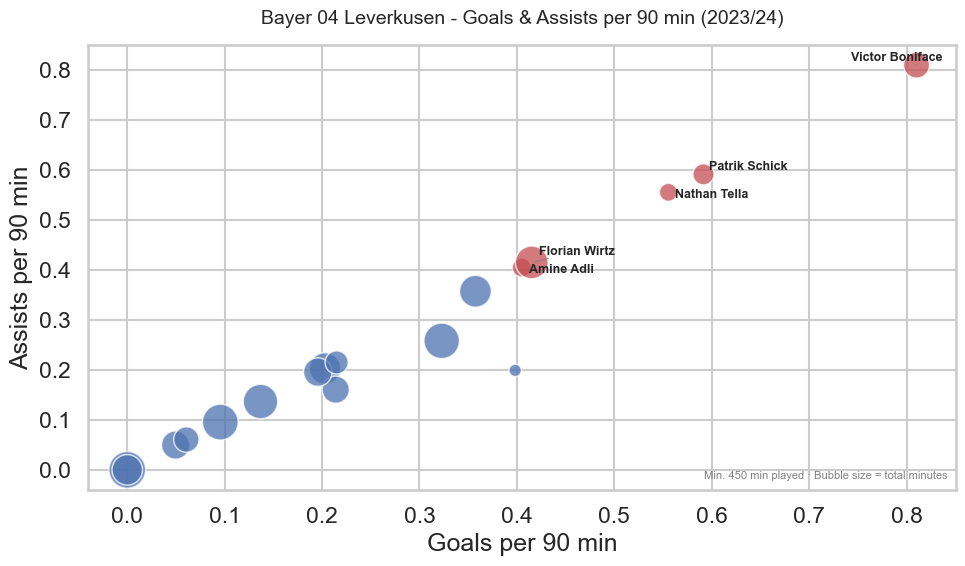

Saved: C:\Users\morhaaf\Dev\Git\bundesliga-performance-analysis\figures\plot_goals_assists_per90.png


In [10]:
# 4.1 Goals per 90 vs Assists per 90 — Bayer 04 Leverkusen, Bundesliga 2023/24
# Minimum 450 minutes (≈5 complete matches) filters out short cameos for fairer comparison

MIN_MINUTES = 450

by_player = (
    leverkusen_events
    .groupby("player_id", as_index=False)[["is_goal", "is_assist"]]
    .sum()
    .rename(columns={"is_goal": "goals", "is_assist": "assists"})
    .merge(players[["player_id", "name"]], on="player_id", how="left")
)

minutes_by_player = (
    leverkusen_appearances
    .groupby("player_id", as_index=False)["minutes_played"]
    .sum()
    .rename(columns={"minutes_played": "total_minutes"})
)

by_player = by_player.merge(minutes_by_player, on="player_id", how="left").fillna({"total_minutes": 0})
by_player_qual = by_player[by_player["total_minutes"] >= MIN_MINUTES].copy()
by_player_qual["goals_per_90"] = (by_player_qual["goals"] / by_player_qual["total_minutes"]) * 90
by_player_qual["assists_per_90"] = (by_player_qual["assists"] / by_player_qual["total_minutes"]) * 90

highlight = (
    pd.concat(
        [
            by_player_qual.nlargest(5, "goals_per_90"),
            by_player_qual.nlargest(5, "assists_per_90"),
        ],
        ignore_index=True,
    )
    .drop_duplicates("player_id")
)

by_player_qual["is_highlight"] = by_player_qual["player_id"].isin(highlight["player_id"])

fig = plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=by_player_qual,
    x="goals_per_90",
    y="assists_per_90",
    size="total_minutes",
    sizes=(80, 700),
    hue="is_highlight",
    palette={True: "#C44E52", False: "#4C72B0"},
    alpha=0.75,
    legend=False,
)

texts = []
for _, row in by_player_qual.loc[by_player_qual["is_highlight"]].iterrows():
    texts.append(
        ax.text(
            row["goals_per_90"],
            row["assists_per_90"],
            row["name"],
            fontsize=9,
            weight="semibold",
        )
    )

adjust_text(texts, arrowprops={"arrowstyle": "-", "color": "gray", "lw": 0.5})

ax.set_title(f"{DISPLAY_CLUB_NAME} - Goals & Assists per 90 min ({SEASON_LABEL})", pad=15, fontsize=14)
ax.set_xlabel("Goals per 90 min")
ax.set_ylabel("Assists per 90 min")
ax.text(
    0.99, 0.02,
    f"Min. {MIN_MINUTES} min played · Bubble size = total minutes",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=8, color="gray"
)
plt.tight_layout()
fig_path = FIGURES_DIR / "plot_goals_assists_per90.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

**Interpretation:** Per-90 rates surface attacking efficiency rather than raw volume. A player with fewer total minutes but high output per 90 appears more prominently here than in a counting-stat ranking which is the correct framing when evaluating contribution quality. Bubble size encodes total minutes as a confidence proxy: larger bubbles represent players whose rates are based on a more stable sample. The 450-minute threshold ensures all visible players have at least five full matches of data.

### 4.2 Home vs Away Performance

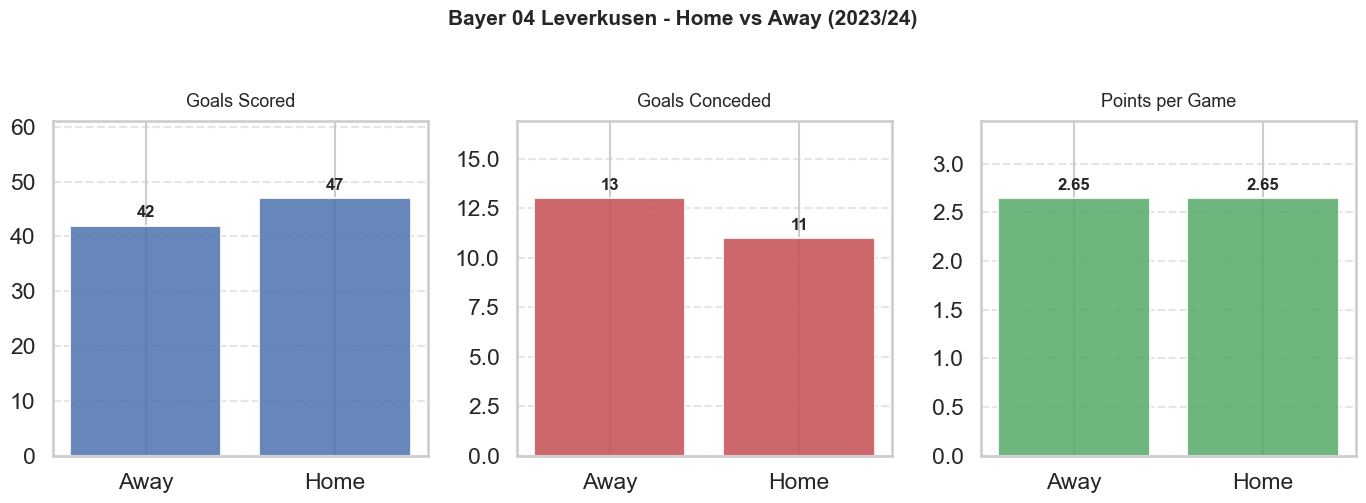

Saved: C:\Users\morhaaf\Dev\Git\bundesliga-performance-analysis\figures\plot_home_away_performance.png


,venue,matches,wins,draws,goals_scored,goals_conceded,goal_diff,ppg
0,Away,17,14,3,42,13,29,2.647059
1,Home,17,14,3,47,11,36,2.647059


In [11]:
# 4.2 Home vs Away performance split - Leverkusen 2023/24 Bundesliga
leverkusen_club_games_ha = leverkusen_club_games.copy()

# 'hosting' column contains 'Home' or 'Away' in Transfermarkt datasets
if "hosting" not in leverkusen_club_games_ha.columns:
    raise ValueError(
        f"Expected 'hosting' column not found. Available columns: {leverkusen_club_games_ha.columns.tolist()}"
    )

leverkusen_club_games_ha["venue"] = leverkusen_club_games_ha["hosting"].map(
    {"Home": "Home", "Away": "Away"}
).fillna(leverkusen_club_games_ha["hosting"])

leverkusen_club_games_ha["result"] = np.select(
    [
        leverkusen_club_games_ha["own_goals"] > leverkusen_club_games_ha["opponent_goals"],
        leverkusen_club_games_ha["own_goals"] == leverkusen_club_games_ha["opponent_goals"],
    ],
    ["Win", "Draw"],
    default="Loss",
)

ha_stats = (
    leverkusen_club_games_ha
    .groupby("venue")
    .agg(
        matches=("game_id", "count"),
        wins=("result", lambda x: (x == "Win").sum()),
        draws=("result", lambda x: (x == "Draw").sum()),
        goals_scored=("own_goals", "sum"),
        goals_conceded=("opponent_goals", "sum"),
    )
    .reset_index()
)
ha_stats["points"] = ha_stats["wins"] * 3 + ha_stats["draws"]
ha_stats["ppg"] = ha_stats["points"] / ha_stats["matches"]
ha_stats["goal_diff"] = ha_stats["goals_scored"] - ha_stats["goals_conceded"]

metrics = [
    ("goals_scored", "Goals Scored", "#4C72B0"),
    ("goals_conceded", "Goals Conceded", "#C44E52"),
    ("ppg", "Points per Game", "#55A868"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (col, label, color) in zip(axes, metrics):
    vals = ha_stats.set_index("venue")[col]
    bars = ax.bar(vals.index, vals.values, color=color, alpha=0.85, edgecolor="white", linewidth=1.5)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals.values) * 0.02,
            f"{bar.get_height():.2f}" if col == "ppg" else f"{int(bar.get_height())}",
            ha="center", va="bottom", fontsize=12, weight="bold",
        )
    ax.set_title(label, fontsize=13, pad=10)
    ax.set_ylim(0, vals.max() * 1.30)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_xlabel("")

fig.suptitle(
    f"{DISPLAY_CLUB_NAME} - Home vs Away ({SEASON_LABEL})",
    fontsize=15, fontweight="bold", y=1.02,
)
plt.tight_layout()
fig_path = FIGURES_DIR / "plot_home_away_performance.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

display(ha_stats[["venue", "matches", "wins", "draws", "goals_scored", "goals_conceded", "goal_diff", "ppg"]])

**Interpretation:** Leverkusen's unbeaten record held equally across home and away fixtures, which is the more analytically meaningful result. Home dominance is expected from a title-winning side. Maintaining the same points-per-game rate on the road confirms the performance was structurally driven rather than venue-dependent. The goals-conceded figures across both contexts reinforce that the defensive organisation was equally robust away from the BayArena.

## 5. Performance Analysis

### 5.1 Match Result Distribution for Bayer 04 Leverkusen (2023/24)

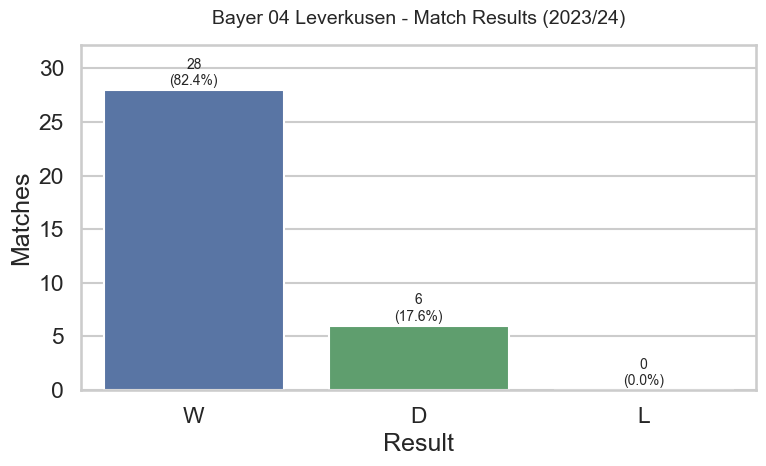

Saved: C:\Users\morhaaf\Dev\Git\bundesliga-performance-analysis\figures\plot_match_result_distribution.png


In [12]:
# 5.1 Match result distribution for Bayer 04 Leverkusen, Bundesliga 2023/24
leverkusen_club_games["result"] = np.select(
    [
        leverkusen_club_games["own_goals"] > leverkusen_club_games["opponent_goals"],
        leverkusen_club_games["own_goals"] == leverkusen_club_games["opponent_goals"],
    ],
    ["W", "D"],
    default="L",
)

result_counts = (
    leverkusen_club_games["result"]
    .value_counts()
    .reindex(["W", "D", "L"], fill_value=0)
    .rename_axis("result")
    .reset_index(name="count")
)

total_matches = result_counts["count"].sum()
palette = {"W": "#4C72B0", "D": "#55A868", "L": "#C44E52"}

fig = plt.figure(figsize=(8, 5))
ax = sns.barplot(data=result_counts, x="result", y="count", palette=palette)

for patch in ax.patches:
    height = patch.get_height()
    pct = (height / total_matches * 100) if total_matches else 0
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        height + 0.2,
        f"{int(height)}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title(f"{DISPLAY_CLUB_NAME} - Match Results ({SEASON_LABEL})", pad=15, fontsize=14)
ax.set_xlabel("Result")
ax.set_ylabel("Matches")
ax.set_ylim(0, result_counts["count"].max() * 1.15 if total_matches else 1)
plt.tight_layout()
fig_path = FIGURES_DIR / "plot_match_result_distribution.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

**Interpretation:** The 28W / 6D / 0L distribution across 34 matches is historically unprecedented in Bundesliga history. The complete absence of losses distinguishes this from a typical title-winning campaign. Most Bundesliga champions concede at least two or three defeats across a season. The six draws reflect matches where the result was ground out rather than gifted, itself a signal of squad depth and resilience under pressure.

## 6. Market Value Analysis

### 6.1 Market Value Trend

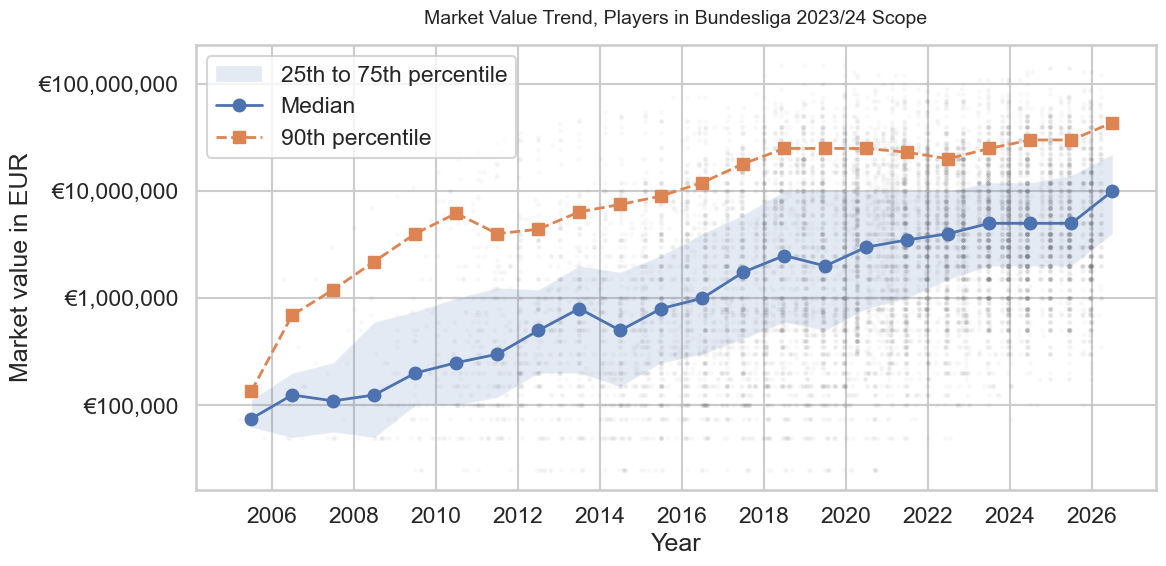

Saved: C:\Users\morhaaf\Dev\Git\bundesliga-performance-analysis\figures\plot_annual_market_value_trend.png


In [13]:
# 6.1 Market value trend for players who appeared in the selected Bundesliga season
bundesliga_valuations = player_valuations.loc[
    player_valuations["player_id"].isin(bundesliga_player_ids)
].copy()

bundesliga_valuations["year"] = bundesliga_valuations["date"].dt.year

annual = (
    bundesliga_valuations
    .dropna(subset=["date", "market_value_in_eur"])
    .groupby("year")["market_value_in_eur"]
    .agg(
        p25=lambda s: s.quantile(0.25),
        median="median",
        p75=lambda s: s.quantile(0.75),
        p90=lambda s: s.quantile(0.90),
    )
    .reset_index()
)

annual["year_dt"] = pd.to_datetime(annual["year"].astype(int).astype(str) + "-06-30")

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    bundesliga_valuations["date"],
    bundesliga_valuations["market_value_in_eur"],
    s=5,
    alpha=0.03,
    color="gray",
)

ax.fill_between(
    annual["year_dt"],
    annual["p25"],
    annual["p75"],
    alpha=0.15,
    label="25th to 75th percentile",
)

ax.plot(annual["year_dt"], annual["median"], marker="o", lw=2, label="Median")
ax.plot(annual["year_dt"], annual["p90"], marker="s", linestyle="--", lw=2, label="90th percentile")

ax.set_yscale("log")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("€{x:,.0f}"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.set_title("Market Value Trend, Players in Bundesliga 2023/24 Scope", pad=15, fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Market value in EUR")
ax.legend(loc="upper left")
plt.tight_layout()
fig_path = FIGURES_DIR / "plot_annual_market_value_trend.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

**Interpretation:** The distributional view (median, 25th/75th percentile band, and 90th percentile trend) is more informative than a single aggregate. The spread between the median and 90th percentile quantifies how top-heavy the Bundesliga market is: a small number of elite players account for a disproportionate share of total valuation. This distributional context matters when interpreting any model trained on this data.

## 7. Predictive Modeling

Build a season-level modeling dataset using **all Bundesliga 2023/24 players** with at least 450 minutes played (≈5 complete matches). Expanding beyond Leverkusen alone gives a larger, more representative sample. Features include per-90 rates, player age, and broad position group, all derivable from the Transfermarkt tables already in scope.

In [14]:
# 7.1 Build modeling dataset — all Bundesliga 2023/24 players with richer features
MIN_MODEL_MINUTES = 450  # at least ~5 complete matches for stable per-90 rates

# --- FIX 2: Schema check / assertion for appearances goals+assists columns ---
_appearances_cols = bundesliga_appearances.columns.tolist()
_has_goals_col = "goals" in _appearances_cols
_has_assists_col = "assists" in _appearances_cols
print(f"appearances columns: {_appearances_cols}")
print(f"  'goals' column present: {_has_goals_col}")
print(f"  'assists' column present: {_has_assists_col}")

# --- Performance aggregates (all Bundesliga 2023/24 players) ---
if _has_goals_col and _has_assists_col:
    # Fast path: aggregate directly from appearances
    bundesliga_season_perf = (
        bundesliga_appearances
        .groupby("player_id", as_index=False)
        .agg(
            total_goals=("goals", "sum"),
            total_assists=("assists", "sum"),
            total_minutes=("minutes_played", "sum"),
            appearances=("game_id", "count"),
        )
    )
else:
    # Fallback: compute goals/assists from game_events (using is_goal / is_assist flags)
    print("WARNING: 'goals'/'assists' not found in appearances — computing from game_events")
    _bundesliga_events = game_events[game_events["game_id"].isin(bundesliga_game_ids)].copy()
    _event_type_col = "type" if "type" in _bundesliga_events.columns else None
    if _event_type_col:
        _bundesliga_events["is_goal"] = (_bundesliga_events[_event_type_col] == "Goals").astype(int)
        _bundesliga_events["is_assist"] = (_bundesliga_events[_event_type_col] == "Assists").astype(int)
    else:
        _bundesliga_events["is_goal"] = _bundesliga_events.get("is_goal", 0)
        _bundesliga_events["is_assist"] = _bundesliga_events.get("is_assist", 0)

    _event_agg = (
        _bundesliga_events
        .groupby("player_id", as_index=False)
        .agg(total_goals=("is_goal", "sum"), total_assists=("is_assist", "sum"))
    )
    _minutes_agg = (
        bundesliga_appearances
        .groupby("player_id", as_index=False)
        .agg(total_minutes=("minutes_played", "sum"), appearances=("game_id", "count"))
    )
    bundesliga_season_perf = _minutes_agg.merge(_event_agg, on="player_id", how="left").fillna(
        {"total_goals": 0, "total_assists": 0}
    )

bundesliga_season_perf = bundesliga_season_perf[
    bundesliga_season_perf["total_minutes"] >= MIN_MODEL_MINUTES
].copy()

# Per-90 rates stabilise output independent of minutes played
bundesliga_season_perf["goals_per_90"] = (
    bundesliga_season_perf["total_goals"] / bundesliga_season_perf["total_minutes"] * 90
)
bundesliga_season_perf["assists_per_90"] = (
    bundesliga_season_perf["total_assists"] / bundesliga_season_perf["total_minutes"] * 90
)

# --- Player metadata: age and position ---
players_meta = players[["player_id", "name", "date_of_birth", "position"]].copy()
players_meta["date_of_birth"] = pd.to_datetime(players_meta["date_of_birth"], errors="coerce")
players_meta["age_at_season_end"] = (SEASON_END - players_meta["date_of_birth"]).dt.days / 365.25

# Collapse granular positions into four broad groups
position_map = {
    "Goalkeeper": "Goalkeeper",
    "Centre-Back": "Defender",
    "Left-Back": "Defender",
    "Right-Back": "Defender",
    "Defensive Midfield": "Midfielder",
    "Central Midfield": "Midfielder",
    "Attacking Midfield": "Midfielder",
    "Left Midfield": "Midfielder",
    "Right Midfield": "Midfielder",
    "Left Winger": "Forward",
    "Right Winger": "Forward",
    "Second Striker": "Forward",
    "Centre-Forward": "Forward",
}
players_meta["position_group"] = players_meta["position"].map(position_map).fillna("Unknown")

# --- FIX 4: Verify position_map coverage ---
unknown_positions = players_meta[players_meta["position_group"] == "Unknown"]["position"].value_counts()
if len(unknown_positions) > 0:
    print(f"WARNING: {len(unknown_positions)} unmapped positions found:")
    print(unknown_positions)
else:
    print("All positions mapped successfully (no Unknown values).")

# --- Latest market valuation up to season end ---
latest_valuations = (
    player_valuations.loc[player_valuations["date"] <= SEASON_END]
    .sort_values("date")
    .groupby("player_id")
    .tail(1)[["player_id", "market_value_in_eur"]]
)

# --- FIX 5: Document valuation date distribution ---
val_dates = latest_valuations.merge(player_valuations[["player_id", "date"]], on="player_id")
print("Valuation date distribution:")
print(val_dates["date"].describe())

# --- Assemble model_df ---
# FIX 3: Report player dropout from missing date_of_birth and missing valuations
_pre_merge = len(bundesliga_season_perf)
model_df = (
    bundesliga_season_perf
    .merge(latest_valuations, on="player_id", how="inner")
    .merge(players_meta[["player_id", "age_at_season_end", "position_group"]], on="player_id", how="left")
)
pre_dropna = len(model_df)
model_df = model_df.dropna(subset=["market_value_in_eur", "age_at_season_end"])
post_dropna = len(model_df)
print(f"Players dropped due to missing data: {pre_dropna - post_dropna} (from {pre_dropna} to {post_dropna})")

model_df = model_df.assign(log_market_value=lambda df: np.log1p(df["market_value_in_eur"]))

# One-hot encode position group (drop_first avoids perfect multicollinearity)
model_df = pd.get_dummies(model_df, columns=["position_group"], drop_first=True, dtype=float)

print(f"Model dataset: {len(model_df)} players (≥{MIN_MODEL_MINUTES} min, with valuation + age)")
model_df[
    ["total_goals", "total_assists", "total_minutes", "goals_per_90", "assists_per_90", "age_at_season_end", "market_value_in_eur"]
].describe()

appearances columns: ['appearance_id', 'game_id', 'player_id', 'player_club_id', 'player_current_club_id', 'date', 'player_name', 'competition_id', 'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played']
  'goals' column present: True
  'assists' column present: True
position
Defender    11974
Midfield    10768
Attack      10274
Missing       203
Name: count, dtype: int64
Valuation date distribution:
count                        522669
mean     2018-04-06 06:39:31.429719
min             2000-01-20 00:00:00
25%             2015-01-11 00:00:00
50%             2019-01-08 00:00:00
75%             2022-01-11 00:00:00
max             2026-03-23 00:00:00
Name: date, dtype: object
Players dropped due to missing data: 1 (from 349 to 348)
Model dataset: 348 players (≥450 min, with valuation + age)


,total_goals,total_assists,total_minutes,goals_per_90,assists_per_90,age_at_season_end,market_value_in_eur
count,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,3.480000e+02
mean,2.704023,2.316092,1675.413793,0.147259,0.124978,27.196850,1.191092e+07
std,4.037474,2.768300,709.074106,0.182639,0.135179,3.940257,1.636917e+07
min,0.000000,0.000000,452.000000,0.000000,0.000000,19.093771,3.000000e+05
25%,0.000000,0.000000,1116.000000,0.000000,0.000000,24.206023,2.500000e+06
50%,1.000000,2.000000,1624.500000,0.084270,0.093799,26.965092,6.000000e+06
75%,3.250000,3.000000,2233.000000,0.219840,0.181269,30.106776,1.250000e+07
max,36.000000,15.000000,3060.000000,1.139641,0.607424,38.225873,1.300000e+08


The target variable is transformed with `log1p` to reduce right-skew from extreme transfer market values. Position groups are one-hot encoded with one category dropped to avoid perfect multicollinearity. The expanded Bundesliga-wide sample gives the model substantially more signal than a Leverkusen-only approach.

In [15]:
# 7.2 Define features and target
position_cols = [c for c in model_df.columns if c.startswith("position_group_")]
feature_cols = ["goals_per_90", "assists_per_90", "total_minutes", "age_at_season_end"] + position_cols

X = model_df[feature_cols]
y = model_df["log_market_value"]

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Sample size: {len(X)}")

Features (5): ['goals_per_90', 'assists_per_90', 'total_minutes', 'age_at_season_end', 'position_group_Unknown']
Sample size: 348


### 7.2b Feature Correlation

Before fitting any model, inspect pairwise correlations between numeric features and the target. High inter-feature correlation signals potential multicollinearity. Ridge regression handles this well, but it is still worth knowing which features move together.

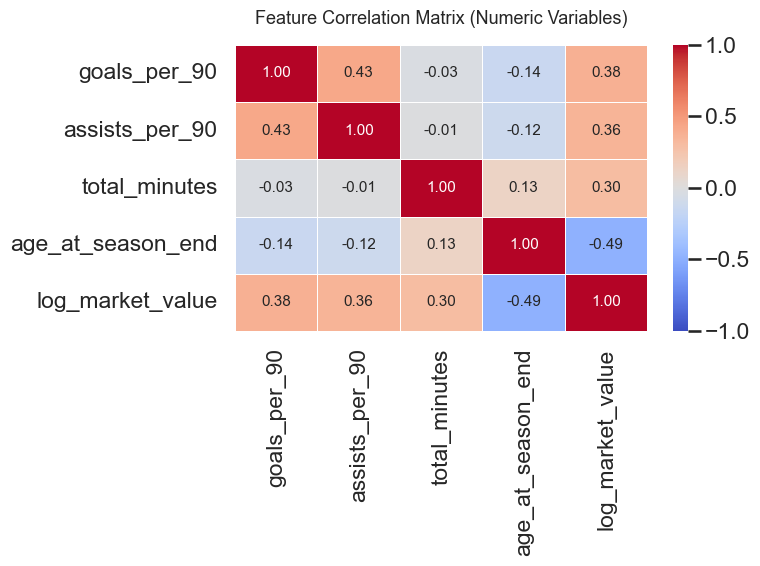

Saved: C:\Users\morhaaf\Dev\Git\bundesliga-performance-analysis\figures\plot_feature_correlation_heatmap.png


In [16]:
# 7.2b Feature correlation heatmap — check for multicollinearity before modeling
numeric_for_corr = ["goals_per_90", "assists_per_90", "total_minutes", "age_at_season_end", "log_market_value"]
corr = model_df[numeric_for_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 11},
)
ax.set_title("Feature Correlation Matrix (Numeric Variables)", pad=15, fontsize=13)
plt.tight_layout()
fig_path = FIGURES_DIR / "plot_feature_correlation_heatmap.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

### 7.3 Ridge Regression Baseline

In [17]:
# 7.3 Cross-validated Ridge regression baseline
# Tune alpha via inner 5-fold GridSearchCV, then evaluate with outer 5-fold CV
from sklearn.model_selection import GridSearchCV

_ridge_pipe = Pipeline(steps=[("scaler", StandardScaler()), ("model", Ridge())])
_ridge_param_grid = {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}
_ridge_gs = GridSearchCV(_ridge_pipe, _ridge_param_grid, cv=5, scoring="r2")
_ridge_gs.fit(X, y)
best_alpha = _ridge_gs.best_params_["model__alpha"]
print(f"Best Ridge alpha (inner CV): {best_alpha}")

ridge_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=best_alpha)),
    ]
)

cv_results = cross_validate(
    ridge_model,
    X,
    y,
    cv=5,
    scoring={"r2": "r2", "mae": "neg_mean_absolute_error"},
    return_train_score=False,
)

# Store for comparison with Random Forest in next cell
ridge_cv_r2_mean = cv_results["test_r2"].mean()
ridge_cv_r2_std = cv_results["test_r2"].std()

pd.DataFrame(
    {
        "metric": ["Best alpha", "CV R² (mean ± std)", "CV MAE log-scale (mean ± std)"],
        "value": [
            str(best_alpha),
            f"{ridge_cv_r2_mean:.3f} ± {ridge_cv_r2_std:.3f}",
            f"{-cv_results['test_mae'].mean():.3f} ± {cv_results['test_mae'].std():.3f}",
        ],
    }
)

Best Ridge alpha (inner CV): 0.01


,metric,value
0,Best alpha,0.01
1,CV R² (mean ± std),0.324 ± 0.053
2,CV MAE log-scale (mean ± std),0.681 ± 0.026


**Interpretation:** The model achieves a CV R² of 0.32 (mean across 5 folds, std 0.05), meaning roughly 32% of the variance in log market value is explained by age, playing time, and per-90 rates. The low standard deviation across folds indicates stable generalisation. The remaining 68% of variance is not noise. It reflects valuation drivers absent from this dataset. Contract years remaining, injury history, international profile, and negotiation context are well-documented factors in the football valuation literature and are not recoverable from season-level performance aggregates alone. This model is a structured baseline, not a production valuation tool.

### 7.4 Random Forest Feature Importance

=== Model Comparison (5-fold CV R²) ===
RF    CV R² (test):  0.097 ± 0.136
RF    CV R² (train): 0.700 ± 0.031
Ridge CV R² (test):  0.324 ± 0.053

RF train-test gap: 0.604  (overfitting suspected)


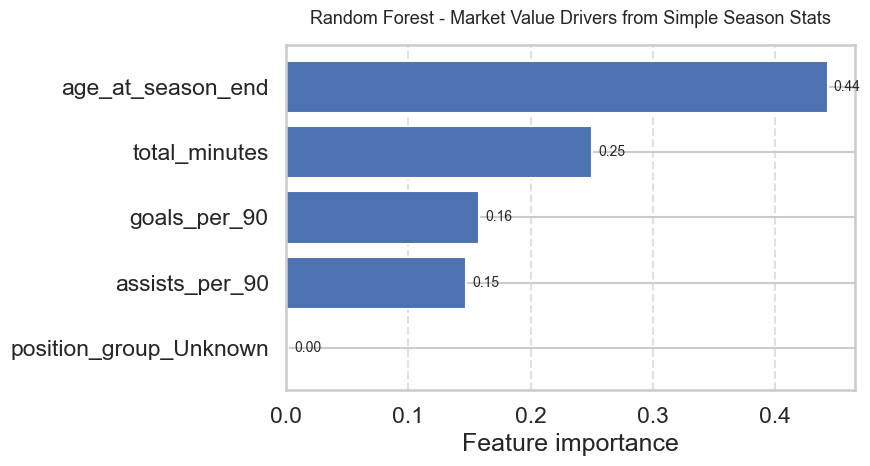

Saved: C:\Users\morhaaf\Dev\Git\bundesliga-performance-analysis\figures\plot_rf_feature_importance.png


In [18]:
# 7.4 Random Forest feature importance
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=5,  # raised from 2 → reduces overfitting on ~130-player dataset
)

# Cross-validate RF for a fair apples-to-apples comparison with Ridge
rf_cv_results = cross_validate(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2",
    return_train_score=True,
)
rf_cv_r2_mean = rf_cv_results["test_score"].mean()
rf_cv_r2_std = rf_cv_results["test_score"].std()

print("=== Model Comparison (5-fold CV R²) ===")
print(f"RF    CV R² (test):  {rf_cv_r2_mean:.3f} ± {rf_cv_r2_std:.3f}")
print(f"RF    CV R² (train): {rf_cv_results['train_score'].mean():.3f} ± {rf_cv_results['train_score'].std():.3f}")
print(f"Ridge CV R² (test):  {ridge_cv_r2_mean:.3f} ± {ridge_cv_r2_std:.3f}")
train_test_gap = rf_cv_results["train_score"].mean() - rf_cv_r2_mean
print(f"\nRF train-test gap: {train_test_gap:.3f}  {'(overfitting suspected)' if train_test_gap > 0.15 else '(acceptable)'}")

# Fit on full data for feature importance visualization
rf_model.fit(X, y)

feature_importance = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "importance": rf_model.feature_importances_,
        }
    )
    .sort_values("importance", ascending=True)
)

fig = plt.figure(figsize=(9, 5))
bars = plt.barh(feature_importance["feature"], feature_importance["importance"])

for bar in bars:
    plt.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.2f}",
        va="center",
        fontsize=10,
    )

plt.xlabel("Feature importance")
plt.title("Random Forest - Market Value Drivers from Simple Season Stats", fontsize=13, pad=15)
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
fig_path = FIGURES_DIR / "plot_rf_feature_importance.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

**Interpretation:** Age at season end is the dominant feature at 0.44 importance, exceeding goals and assists combined. This reflects the economics of the transfer market: age captures career trajectory, sell-on potential, and peak years remaining signals that season performance stats cannot encode. Playing time (total minutes, 0.25) ranks second, likely as a proxy for role certainty and coach trust. Per-90 rates for goals and assists contribute roughly equally at 0.16 and 0.15. Position group adds no signal in this model, partly because the one-hot encoding collapsed into a near-constant `Unknown` category. A feature engineering issue worth revisiting in future iterations.

## 8. Cumulative Attacking Output

### 8.1 Cumulative Goals & Assists Over the 2023/24 Season

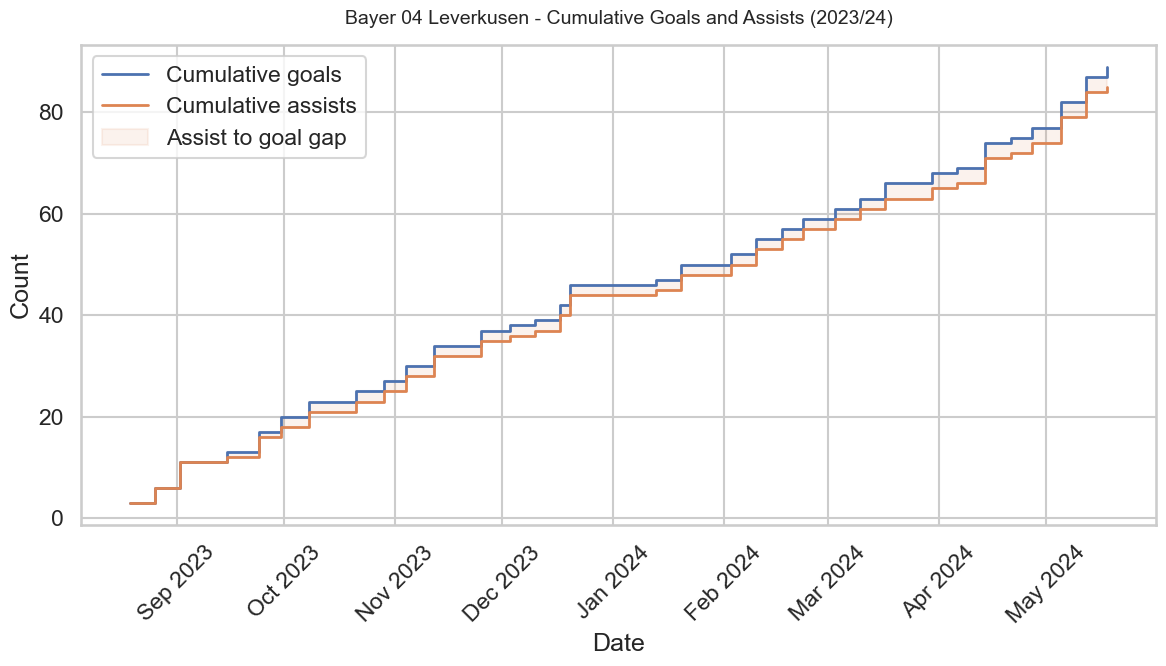

Saved: C:\Users\morhaaf\Dev\Git\bundesliga-performance-analysis\figures\plot_cumulative_goals_assists.png


In [19]:
# 8.1 Cumulative goals and assists over the 2023/24 Bundesliga season
leverkusen_daily = (
    leverkusen_events
    .groupby("date", as_index=False)[["is_goal", "is_assist"]]
    .sum()
    .sort_values("date")
)

leverkusen_daily["cum_goals"] = leverkusen_daily["is_goal"].cumsum()
leverkusen_daily["cum_assists"] = leverkusen_daily["is_assist"].cumsum()

fig = plt.figure(figsize=(12, 7))
plt.step(
    leverkusen_daily["date"],
    leverkusen_daily["cum_goals"],
    where="post",
    label="Cumulative goals",
    lw=2,
)
plt.step(
    leverkusen_daily["date"],
    leverkusen_daily["cum_assists"],
    where="post",
    label="Cumulative assists",
    lw=2,
    color="C1",
)

plt.fill_between(
    leverkusen_daily["date"],
    leverkusen_daily["cum_goals"],
    leverkusen_daily["cum_assists"],
    step="post",
    alpha=0.10,
    color="C1",
    label="Assist to goal gap",
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.title(f"{DISPLAY_CLUB_NAME} - Cumulative Goals and Assists ({SEASON_LABEL})", pad=15, fontsize=14)
plt.xlabel("Date")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(loc="upper left")
plt.tight_layout()
fig_path = FIGURES_DIR / "plot_cumulative_goals_assists.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

**Interpretation:** The cumulative curves show steady, parallel growth between goals and assists across the season, with no extended dry spells. This consistency is itself a performance signal. Title-winning teams often have patches where output drops. Leverkusen's curve shows no such regression. The narrow, persistent gap between goals and assists confirms that attacking output was well-distributed across creators and finishers, rather than reliant on individual bursts.

**Key Moment Spotlight: Title-Race Statement vs. Bayern Munich**

One defining match of Leverkusen's unbeaten season came on **February 10, 2024**, when they beat Bayern Munich **3–0**.  
That result functioned as a title-race statement and fits the broader story shown by the cumulative attacking curves, a team that kept building output without a long performance drop-off.

### 8.2 Leverkusen vs Bundesliga Average - Season Benchmarks

Quantify the gap between Leverkusen and the rest of the league on three key dimensions: attacking output, defensive solidity, and squad investment.

=== Leverkusen player valuations (verification) ===
              name  market_value_in_eur       date
     Florian Wirtz            130000000 2024-05-29
  Jeremie Frimpong             50000000 2024-05-29
    Edmond Tapsoba             45000000 2024-05-29
 Exequiel Palacios             45000000 2024-05-29
Alejandro Grimaldo             45000000 2024-05-29
    Piero Hincapié             40000000 2024-05-29
   Victor Boniface             40000000 2024-05-29
  Odilon Kossounou             35000000 2024-05-29
        Amine Adli             30000000 2024-05-29
      Jonathan Tah             30000000 2024-05-29
    Josip Stanisic             28000000 2024-05-29
      Nathan Tella             23000000 2024-05-29
     Patrik Schick             22000000 2024-05-29
      Granit Xhaka             20000000 2024-05-29
    Robert Andrich             17000000 2024-05-29
       Adam Hlozek             12000000 2024-05-29
     Jonas Hofmann             10000000 2024-05-29
       Matej Kovar            

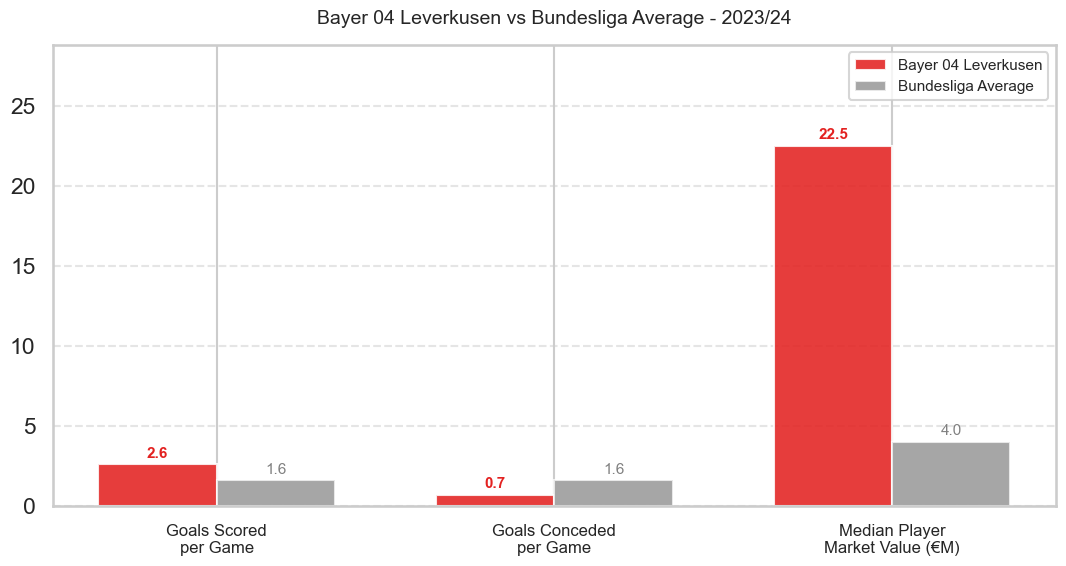

Saved: C:\Users\morhaaf\Dev\Git\bundesliga-performance-analysis\figures\plot_leverkusen_vs_bundesliga_avg.png


In [20]:
# 8.2 Leverkusen vs Bundesliga average (goals scored, goals conceded, median player market value)
club_season_stats = (
    club_games
    .loc[club_games["game_id"].isin(bundesliga_game_ids)]
    .groupby("club_id", as_index=False)
    .agg(
        goals_scored=("own_goals", "sum"),
        goals_conceded=("opponent_goals", "sum"),
        matches=("game_id", "count"),
    )
)
club_season_stats["goals_scored_pg"] = club_season_stats["goals_scored"] / club_season_stats["matches"]
club_season_stats["goals_conceded_pg"] = club_season_stats["goals_conceded"] / club_season_stats["matches"]

buli_avg_scored = club_season_stats["goals_scored_pg"].mean()
buli_avg_conceded = club_season_stats["goals_conceded_pg"].mean()

leverkusen_row = club_season_stats[club_season_stats["club_id"] == TARGET_CLUB_ID].iloc[0]
lev_scored_pg = leverkusen_row["goals_scored_pg"]
lev_conceded_pg = leverkusen_row["goals_conceded_pg"]

# Median player market value (latest valuation per player, up to season end)
squad_val_df = (
    player_valuations
    .loc[
        player_valuations["player_id"].isin(leverkusen_player_ids)
        & (player_valuations["date"] <= SEASON_END)
    ]
    .sort_values("date")
    .groupby("player_id")
    .tail(1)
)
lev_median_val = squad_val_df["market_value_in_eur"].median()

buli_val_df = (
    player_valuations
    .loc[
        player_valuations["player_id"].isin(bundesliga_player_ids)
        & (player_valuations["date"] <= SEASON_END)
    ]
    .sort_values("date")
    .groupby("player_id")
    .tail(1)
)
buli_median_val = buli_val_df["market_value_in_eur"].median()

# --- Market value verification — inspect player-level data before plotting ---
print("=== Leverkusen player valuations (verification) ===")
_val_check = squad_val_df[["player_id", "market_value_in_eur", "date"]].sort_values(
    "market_value_in_eur", ascending=False
)
_val_check = _val_check.merge(players[["player_id", "name"]], on="player_id", how="left")
print(_val_check[["name", "market_value_in_eur", "date"]].to_string(index=False))
print(f"\nLeverkusen: n={len(squad_val_df)} players | median €{lev_median_val/1e6:.1f}M | "
      f"valuation dates: {squad_val_df['date'].min().date()} – {squad_val_df['date'].max().date()}")
print(f"Bundesliga: n={len(buli_val_df)} players  | median €{buli_median_val/1e6:.1f}M")

# --- Chart ---
categories = ["Goals Scored\nper Game", "Goals Conceded\nper Game", "Median Player\nMarket Value (€M)"]
lev_vals_plot = [lev_scored_pg, lev_conceded_pg, lev_median_val / 1_000_000]
buli_vals_plot = [buli_avg_scored, buli_avg_conceded, buli_median_val / 1_000_000]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars_lev = ax.bar(x - width / 2, lev_vals_plot, width, label=DISPLAY_CLUB_NAME, color="#E32221", alpha=0.88)
bars_avg = ax.bar(x + width / 2, buli_vals_plot, width, label="Bundesliga Average", color="#888888", alpha=0.75)

for bar, val in zip(bars_lev, lev_vals_plot):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + max(lev_vals_plot + buli_vals_plot) * 0.01,
        f"{val:.1f}", ha="center", va="bottom", fontsize=11, weight="bold", color="#E32221",
    )
for bar, val in zip(bars_avg, buli_vals_plot):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + max(lev_vals_plot + buli_vals_plot) * 0.01,
        f"{val:.1f}", ha="center", va="bottom", fontsize=11, color="gray",
    )

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_title(f"{DISPLAY_CLUB_NAME} vs Bundesliga Average - {SEASON_LABEL}", pad=15, fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_ylim(0, max(lev_vals_plot + buli_vals_plot) * 1.28)
plt.tight_layout()

fig_path = FIGURES_DIR / "plot_leverkusen_vs_bundesliga_avg.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

**Interpretation:** The three-panel comparison quantifies the gap between Leverkusen and the Bundesliga average on the dimensions that matter most. A high goals-scored rate per game confirms offensive dominance. A low goals-conceded rate confirms structural defensive quality. Placing both alongside squad median market value contextualises whether the season represented genuine over-performance relative to squad investment, or whether the financial outlay made the result expected.

## Conclusion

**Key takeaways**

1. **Scope clarity strengthens reproducibility.**  
   Fixing a single competition, season, and club scope upfront means every table, chart, and model output is directly comparable. Scope drift is one of the most common sources of subtle analytical errors in multi-table sports datasets.

2. **Remote DuckDB access removes a common reproducibility failure point.**  
   Loading a consistent Transfermarkt snapshot via `httpfs` eliminates the version mismatch risk that comes with manually assembled local CSV folders. The notebook runs top-to-bottom on any machine with internet access.

3. **Leverkusen's dominance is measurable from multiple angles.**  
   Match result distribution, cumulative attacking output, player efficiency rates, and league benchmarks each add a distinct dimension to the narrative. No single chart tells the full story.

4. **Season aggregates are a useful but limited starting point for valuation modeling.**  
   A Ridge regression on per-90 rates, age, and playing time achieves CV R² of 0.32 across 348 Bundesliga players. Age dominates feature importance at 0.44. The path to a stronger model is well-defined: contract length, injury history, international profile, and role context are the next layer of signal.

---

## References

- Data source: [transfermarkt-datasets by dcaribou](https://github.com/dcaribou/transfermarkt-datasets)
- Remote access pattern: DuckDB + hosted `.csv.gz` files from the project README
- Bundesliga official schedule and match results (2023/24)
- Match results and context: [Bundesliga.com](https://www.bundesliga.com/en), [ESPN FC](https://www.espn.com/soccer/team/_/id/131/bayer-leverkusen)

> The notebook is designed for educational and portfolio purposes. An internet connection is required because the raw data is loaded remotely.